<a href="https://colab.research.google.com/github/ShailenB/POC/blob/main/aerofit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Importing relevant libs:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/drive/MyDrive/aerofit_treadmill.csv')

In [ ]:
df

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47
...,...,...,...,...,...,...,...,...,...
175,KP781,40,Male,21,Single,6,5,83416,200
176,KP781,42,Male,18,Single,5,4,89641,200
177,KP781,45,Male,16,Single,5,5,90886,160
178,KP781,47,Male,18,Partnered,4,5,104581,120


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [ ]:
df.isna().sum()


,0
Product,0
Age,0
Gender,0
Education,0
MaritalStatus,0
Usage,0
Fitness,0
Income,0
Miles,0


In [ ]:
df.head(2)

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75


In [ ]:
round(df.describe(),2)

,Age,Education,Usage,Fitness,Income,Miles
count,180.00,180.00,180.00,180.00,180.00,180.00
mean,28.79,15.57,3.46,3.31,53719.58,103.19
std,6.94,1.62,1.08,0.96,16506.68,51.86
min,18.00,12.00,2.00,1.00,29562.00,21.00
25%,24.00,14.00,3.00,3.00,44058.75,66.00
50%,26.00,16.00,3.00,3.00,50596.50,94.00
75%,33.00,16.00,4.00,4.00,58668.00,114.75
max,50.00,21.00,7.00,5.00,104581.00,360.00


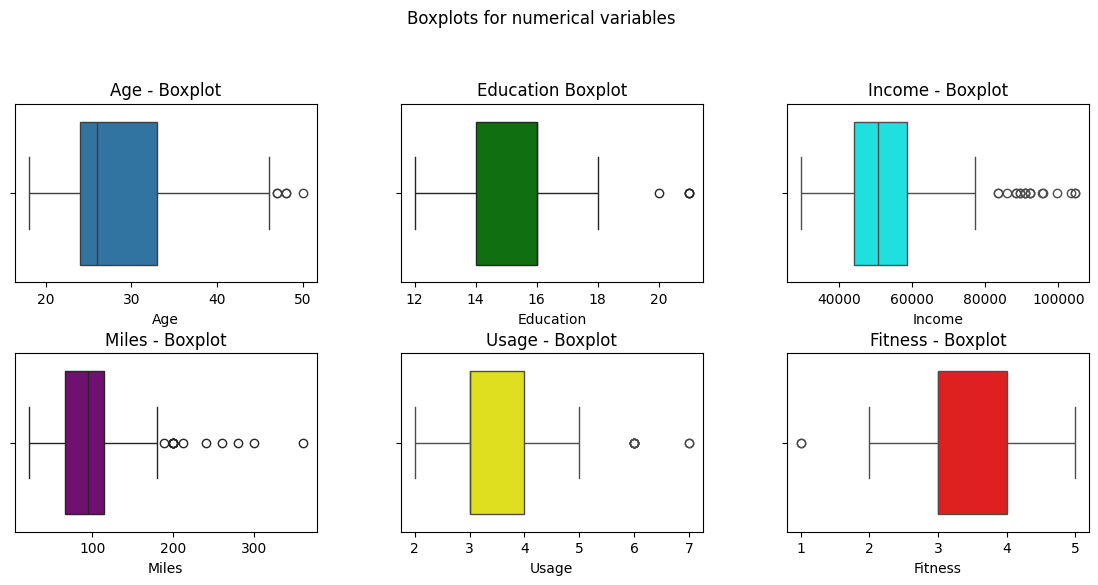

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12,6), )
fig.suptitle('Boxplots for numerical variables')
fig.tight_layout(pad=3)
sns.boxplot(data=df, x='Age', ax=ax[0,0]).set_title('Age - Boxplot')
sns.boxplot(data=df, x='Education', ax=ax[0,1], color='green').set_title('Education Boxplot')
sns.boxplot(data=df, x='Income', ax=ax[0,2], color='cyan').set_title('Income - Boxplot')
sns.boxplot(data=df, x='Miles', ax=ax[1,0], color='purple').set_title('Miles - Boxplot')
sns.boxplot(data=df, x='Usage', ax=ax[1,1], color='yellow').set_title('Usage - Boxplot')
sns.boxplot(data=df, x='Fitness', ax=ax[1,2], color='red').set_title('Fitness - Boxplot')
plt.show()

In [ ]:
IQ_R=[]
MxVal=[]
UpperLimit=[]
OutLierCount=[]
des=df.describe().columns
for i in des:
  kk=df[i].quantile(0.75) - df[i].quantile(0.25)
  jj=df[i].quantile(0.75) + 1.5*kk
  ll=len(df[df[i]>=jj])
  OutLierCount.append(ll)
  UpperLimit.append(jj)
  MxVal.append(df[i].max())
  IQ_R.append(kk)
IQ_RA=pd.DataFrame(des)
IQ_RA.columns=['Parameter']
IQ_RA.set_index('Parameter', inplace=True)
IQ_RA['IQR']=IQ_R
IQ_RA['Max_Val']=MxVal
IQ_RA['Upper_Limit']=UpperLimit
IQ_RA['Outliers_Count']=OutLierCount
IQ_RA

,IQR,Max_Val,Upper_Limit,Outliers_Count
Parameter,,,,
Age,9.00,50,46.500,5
Education,2.00,21,19.000,4
Usage,1.00,7,5.500,9
Fitness,1.00,5,5.500,0
Income,14609.25,104581,80581.875,19
Miles,48.75,360,187.875,13


In [ ]:
df_f=df[df.Age<=IQ_RA.loc['Age','Upper_Limit']]
df_f=df_f[df_f.Education<=IQ_RA.loc['Education','Upper_Limit']]
df_f=df_f[df_f.Income<=IQ_RA.loc['Income','Upper_Limit']]
df_f.reset_index(drop=True, inplace=True)
df_f.shape

(156, 9)

In [ ]:
df_f.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        156 non-null    object
 1   Age            156 non-null    int64 
 2   Gender         156 non-null    object
 3   Education      156 non-null    int64 
 4   MaritalStatus  156 non-null    object
 5   Usage          156 non-null    int64 
 6   Fitness        156 non-null    int64 
 7   Income         156 non-null    int64 
 8   Miles          156 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 11.1+ KB


In [ ]:
round(df_f.describe(),2)

,Age,Education,Usage,Fitness,Income,Miles
count,156.00,156.00,156.00,156.00,156.00,156.00
mean,27.80,15.27,3.27,3.13,48616.15,93.08
std,6.14,1.35,0.95,0.85,9585.96,39.26
min,18.00,12.00,2.00,1.00,29562.00,21.00
25%,23.00,14.00,3.00,3.00,42069.00,66.00
50%,25.50,16.00,3.00,3.00,48891.00,85.00
75%,32.00,16.00,4.00,3.00,53796.00,106.00
max,46.00,18.00,7.00,5.00,77191.00,240.00


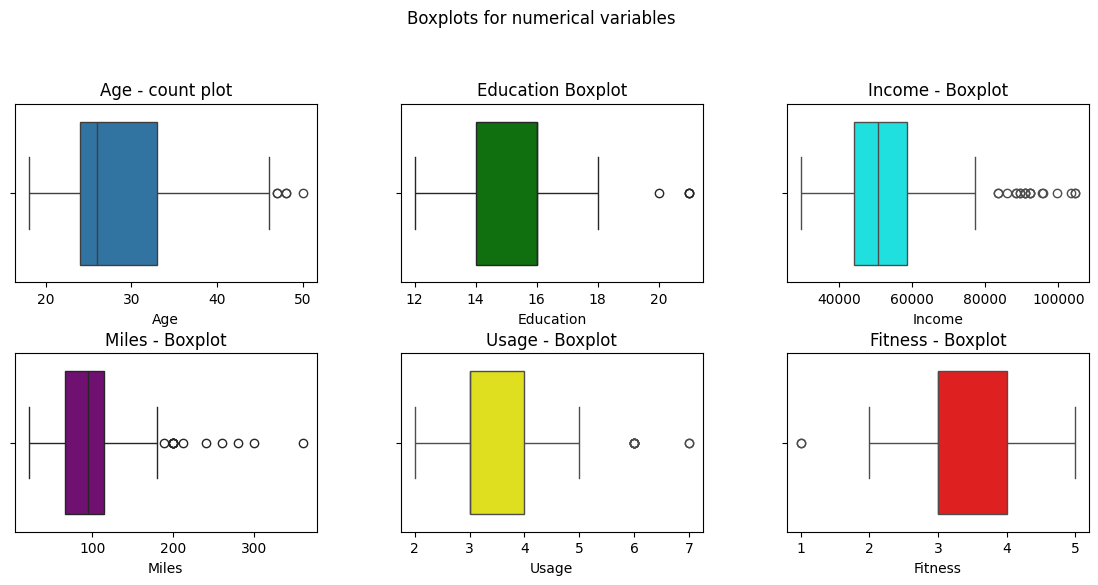

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12,6), )
fig.suptitle('Boxplots for numerical variables')
fig.tight_layout(pad=3)
sns.boxplot(data=df, x='Age', ax=ax[0,0]).set_title('Age - count plot')
sns.boxplot(data=df, x='Education', ax=ax[0,1], color='green').set_title('Education Boxplot')
sns.boxplot(data=df, x='Income', ax=ax[0,2], color='cyan').set_title('Income - Boxplot')
sns.boxplot(data=df, x='Miles', ax=ax[1,0], color='purple').set_title('Miles - Boxplot')
sns.boxplot(data=df, x='Usage', ax=ax[1,1], color='yellow').set_title('Usage - Boxplot')
sns.boxplot(data=df, x='Fitness', ax=ax[1,2], color='red').set_title('Fitness - Boxplot')
plt.show()

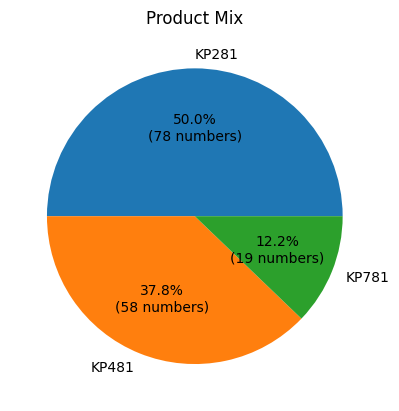

In [ ]:
def func(pct, allvalues):
    absolute = int(pct / 100.*np.sum(allvalues))
    return "{:.1f}%\n({:d} numbers)".format(pct, absolute)

plt.pie(df_f.Product.value_counts(), labels=df_f.Product.unique(), autopct=lambda pct: func(pct, df_f.Product.value_counts()))
plt.title('Product Mix')
plt.show()

In [ ]:
df_f['AgeGroups'] = pd.cut(df_f.Age, [16, 24, 32, 40, 50], right=False, labels=['Sub_24', '24_to_32', '32_to_40', '40_Plus'])

In [ ]:
df_f.AgeGroups.unique()

['Sub_24', '24_to_32', '32_to_40', '40_Plus']
Categories (4, object): ['Sub_24' < '24_to_32' < '32_to_40' < '40_Plus']

In [ ]:
df_f['Income_Group']= pd.cut(df_f.Income, [20000, 40000, 50000, 60000, 100000], right=False, labels=['Sub_40K', '40K_to_50K', '50K_to_60K', '60K_&_above'])

In [ ]:
df_f.Income_Group.unique()

['Sub_40K', '40K_to_50K', '50K_to_60K', '60K_&_above']
Categories (4, object): ['Sub_40K' < '40K_to_50K' < '50K_to_60K' < '60K_&_above']

In [ ]:
df_f.columns

Index(['Product', 'Age', 'Gender', 'Education', 'MaritalStatus', 'Usage',
       'Fitness', 'Income', 'Miles', 'AgeGroups', 'Income_Group'],
      dtype='object')

<ipython-input-11-b2fc9e078355>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=ax[0,0], data=df_f, y='Product', order=df_f.Product.value_counts(ascending=True).index, palette=sns.color_palette('bright'))
<ipython-input-11-b2fc9e078355>:4: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.countplot(ax=ax[0,0], data=df_f, y='Product', order=df_f.Product.value_counts(ascending=True).index, palette=sns.color_palette('bright'))
<ipython-input-11-b2fc9e078355>:6: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.countplot(ax=ax[0,1], data=df_f, y='Product', hue = 'Gender', order=df_f.Product.value_counts(ascending=True).index, palette=sns.color_palette('bright'))
<ipython-input-11-b2fc9e078355>:7: UserWarning: The palette list has more 

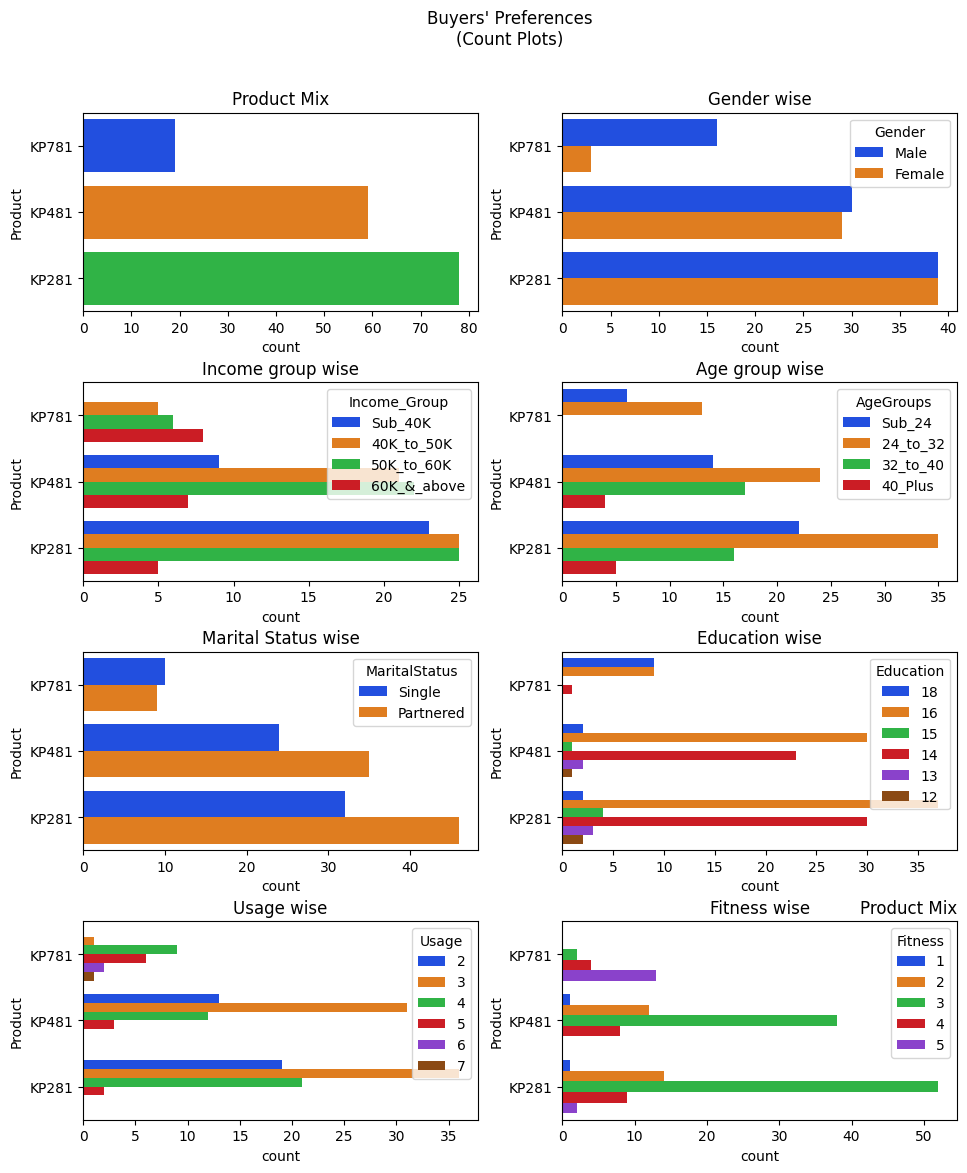

In [ ]:

fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(10,12) )
fig.suptitle("Buyers' Preferences"+'\n'+"(Count Plots)")
fig.tight_layout(pad=3)
sns.countplot(ax=ax[0,0], data=df_f, y='Product', order=df_f.Product.value_counts(ascending=True).index, palette=sns.color_palette('bright'))
plt.title("Product Mix", loc='right')
sns.countplot(ax=ax[0,1], data=df_f, y='Product', hue = 'Gender', order=df_f.Product.value_counts(ascending=True).index, palette=sns.color_palette('bright'))
sns.countplot(ax=ax[1,0], data=df_f, y='Product', hue = 'Income_Group', order=df_f.Product.value_counts(ascending=True).index, palette=sns.color_palette('bright'))
sns.countplot(ax=ax[1,1], data=df_f, y='Product', hue = 'AgeGroups', order=df_f.Product.value_counts(ascending=True).index, palette=sns.color_palette('bright'))
sns.countplot(ax=ax[2,0], data=df_f, y='Product', hue = 'MaritalStatus', order=df_f.Product.value_counts(ascending=True).index, palette=sns.color_palette('bright'))
sns.countplot(ax=ax[2,1], data=df_f, y='Product', hue = 'Education',hue_order=[18,16,15,14,13,12], order=df_f.Product.value_counts(ascending=True).index, palette=sns.color_palette('bright'))
sns.countplot(ax=ax[3,0], data=df_f, y='Product', hue = 'Usage', order=df_f.Product.value_counts(ascending=True).index, palette=sns.color_palette('bright'))
sns.countplot(ax=ax[3,1], data=df_f, y='Product', hue = 'Fitness', order=df_f.Product.value_counts(ascending=True).index, palette=sns.color_palette('bright'))
ax[0,0].set_title("Product Mix")
ax[0,1].title.set_text("Gender wise")
ax[0,1].title.loc='right'
ax[1,0].title.set_text("Income group wise")
ax[1,1].title.set_text("Age group wise")
ax[2,0].title.set_text("Marital Status wise")
ax[2,1].title.set_text("Education wise")
ax[3,0].title.set_text("Usage wise")
ax[3,1].title.set_text("Fitness wise")
plt.show()

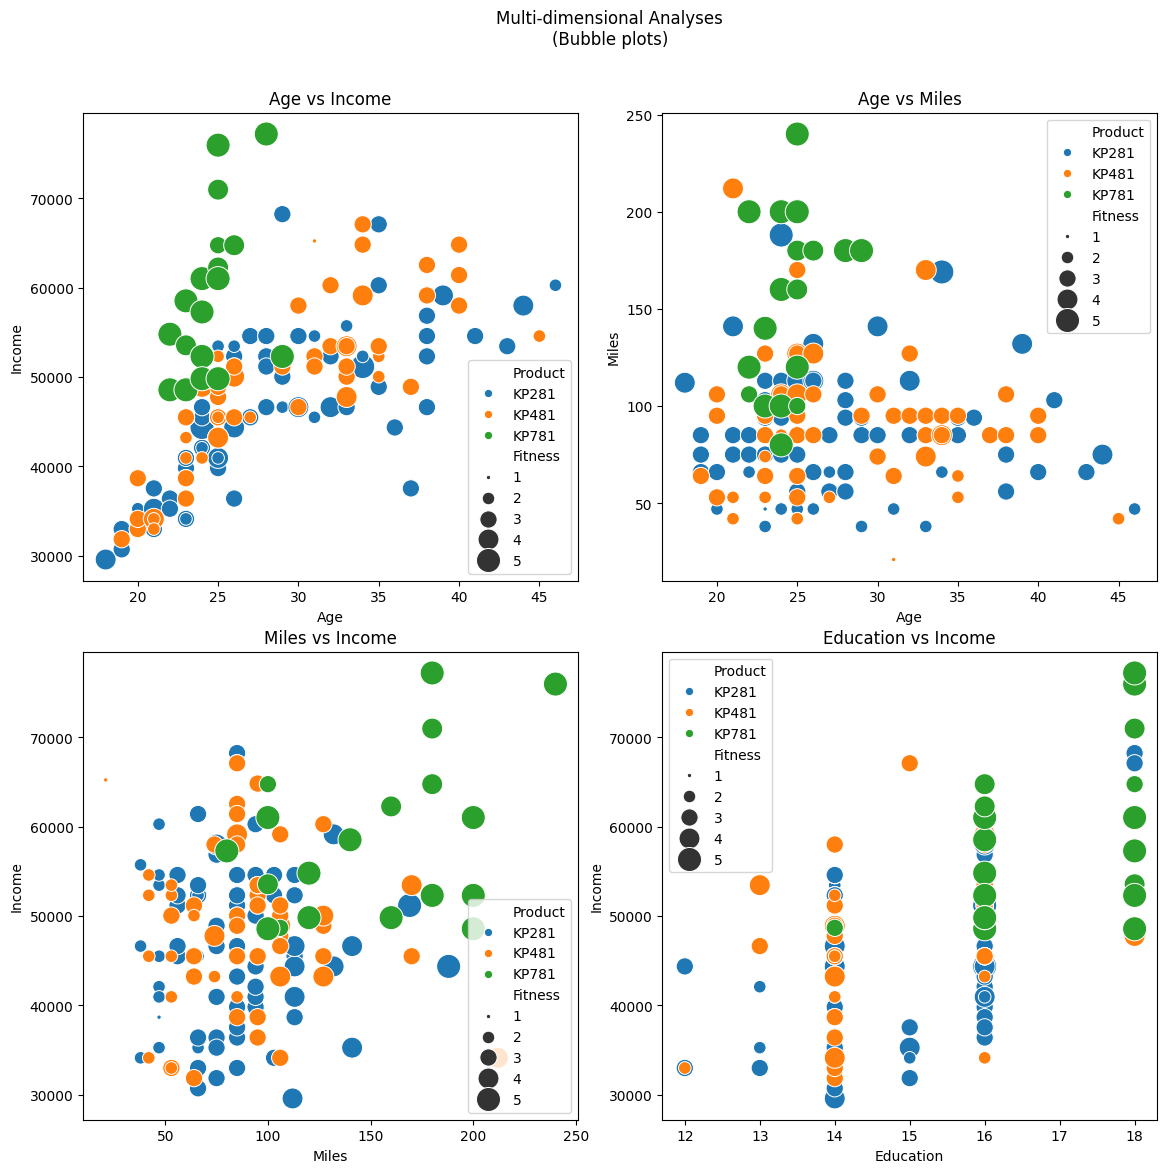

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12,12))
fig.suptitle("Multi-dimensional Analyses"+'\n'+"(Bubble plots)")
fig.tight_layout(pad=3)
sns.scatterplot(ax=ax[0,0], data=df_f, x='Age', y='Income', hue='Product',size='Fitness', sizes=(10, 300), hue_order=['KP281', 'KP481', 'KP781']).legend(loc='lower right')
ax[0,0].title.set_text("Age vs Income")
sns.scatterplot(ax=ax[0,1], data=df_f, x='Age', y='Miles', hue='Product',size='Fitness', sizes=(10, 300), hue_order=['KP281', 'KP481', 'KP781']).legend(loc='upper right')
ax[0,1].title.set_text("Age vs Miles")
sns.scatterplot(ax=ax[1,0], data=df_f, y='Income', x='Miles', hue='Product',size='Fitness', sizes=(10, 300), hue_order=['KP281', 'KP481', 'KP781']).legend(loc='lower right')
ax[1,0].title.set_text("Miles vs Income")
sns.scatterplot(ax=ax[1,1], data=df_f, x='Education', y='Income', hue='Product',size='Fitness', sizes=(10, 300), hue_order=['KP281', 'KP481', 'KP781']).legend(loc='upper left')
ax[1,1].title.set_text("Education vs Income")
plt.show()

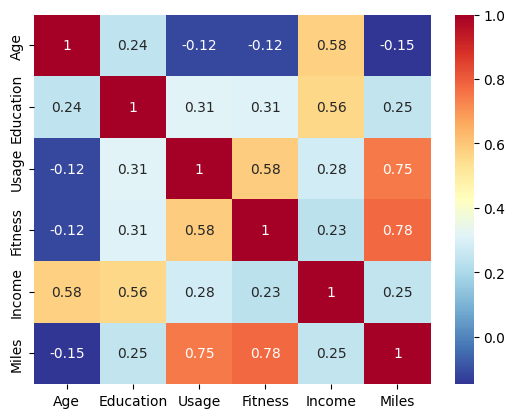

In [ ]:
sns.heatmap(df_f.corr(method='pearson', numeric_only=True), annot=True, cmap='RdYlBu_r')
plt.show()

In [ ]:
dfCorMatrix=df_f.corr(method='pearson', numeric_only=True).round(2)
dfCorMatrix.style.background_gradient(cmap='coolwarm')

,Age,Education,Usage,Fitness,Income,Miles
Age,1.000000,0.240000,-0.120000,-0.120000,0.580000,-0.150000
Education,0.240000,1.000000,0.310000,0.310000,0.560000,0.250000
Usage,-0.120000,0.310000,1.000000,0.580000,0.280000,0.750000
Fitness,-0.120000,0.310000,0.580000,1.000000,0.230000,0.780000
Income,0.580000,0.560000,0.280000,0.230000,1.000000,0.250000
Miles,-0.150000,0.250000,0.750000,0.780000,0.250000,1.000000


In [ ]:
pd.crosstab( df_f.Product, columns=df_f.Gender, margins=True, margins_name='Total', normalize='all' ).round(2)

Gender,Female,Male,Total
Product,,,
KP281,0.25,0.25,0.50
KP481,0.19,0.19,0.38
KP781,0.02,0.10,0.12
Total,0.46,0.54,1.00


In [ ]:
ctGen['Male']

Product
KP281    0.46
KP481    0.35
KP781    0.19
Name: Male, dtype: float64

In [ ]:
pd.crosstab( index=df_f.Product, columns=df_f.MaritalStatus, margins=True, margins_name='Total', normalize=True).round(2)

In [ ]:
CTabGndr= pd.crosstab( index=df_f.Product,margins='Total', columns=df_f.Gender)
CTabGndr['Female_Given_Product']=round(CTabGndr.Female/CTabGndr.All,2)
CTabGndr['Male_Given_Product']=round(CTabGndr.Male/CTabGndr.All,2)
CTabGndr

Gender,Female,Male,All,Female_Given_Product,Male_Given_Product
Product,,,,,
KP281,39,39,78,0.50,0.50
KP481,29,30,59,0.49,0.51
KP781,3,16,19,0.16,0.84
All,71,85,156,0.46,0.54


In [ ]:
CTabMaritalStatus= pd.crosstab( index=df_f.Product,margins='Total', columns=df_f.MaritalStatus)
CTabMaritalStatus['Part_given_Prod']=round(CTabMaritalStatus.Partnered/CTabMaritalStatus.All,2)
CTabMaritalStatus['Single_given_Prod']=round(CTabMaritalStatus.Single/CTabMaritalStatus.All,2)
CTabMaritalStatus

MaritalStatus,Partnered,Single,All,Part_given_Prod,Single_given_Prod
Product,,,,,
KP281,46,32,78,0.59,0.41
KP481,35,24,59,0.59,0.41
KP781,9,10,19,0.47,0.53
All,90,66,156,0.58,0.42


In [ ]:
CTabAgeGrp= pd.crosstab( index=df_f.Product,margins='Total', columns=df_f.AgeGroups)
CTabAgeGrp['Sub24_Given_Prod']=round(CTabAgeGrp['Sub_24']/CTabAgeGrp.All,2)
CTabAgeGrp['24_to_32_Given_Prod']=round(CTabAgeGrp['24_to_32']/CTabAgeGrp.All,2)
CTabAgeGrp['32_to_40_Given_Prod']=round(CTabAgeGrp['32_to_40']/CTabAgeGrp.All,2)
CTabAgeGrp['40_Plus_Given_Prod']=round(CTabAgeGrp['40_Plus']/CTabAgeGrp.All,2)
CTabAgeGrp

AgeGroups,Sub_24,24_to_32,32_to_40,40_Plus,All,Sub24_Given_Prod,24_to_32_Given_Prod,32_to_40_Given_Prod,40_Plus_Given_Prod
Product,,,,,,,,,
KP281,22,35,16,5,78,0.28,0.45,0.21,0.06
KP481,14,24,17,4,59,0.24,0.41,0.29,0.07
KP781,6,13,0,0,19,0.32,0.68,0.00,0.00
All,42,72,33,9,156,0.27,0.46,0.21,0.06


In [ ]:
CTIncomeGrp= pd.crosstab( index=df_f.Product,margins='Total', columns=df_f.Income_Group)
CTIncomeGrp['Sub_40K_Given_Prod']=round(CTIncomeGrp['Sub_40K']/CTIncomeGrp.All,2)
CTIncomeGrp['40K_to_50K_Given_Prod']=round(CTIncomeGrp['40K_to_50K']/CTIncomeGrp.All,2)
CTIncomeGrp['50K_to_60K_Given_Prod']=round(CTIncomeGrp['50K_to_60K']/CTIncomeGrp.All,2)
CTIncomeGrp['60K_&_above_Given_Prod']=round(CTIncomeGrp['60K_&_above']/CTIncomeGrp.All,2)
CTIncomeGrp

Income_Group,Sub_40K,40K_to_50K,50K_to_60K,60K_&_above,All,Sub_40K_Given_Prod,40K_to_50K_Given_Prod,50K_to_60K_Given_Prod,60K_&_above_Given_Prod
Product,,,,,,,,,
KP281,23,25,25,5,78,0.29,0.32,0.32,0.06
KP481,9,21,22,7,59,0.15,0.36,0.37,0.12
KP781,0,5,6,8,19,0.00,0.26,0.32,0.42
All,32,51,53,20,156,0.21,0.33,0.34,0.13


In [ ]:
CTabGndr['Female_Given_Product']=round(CTabGndr.Female/CTabGndr.All,2)
CTabGndr['Male_Given_Product']=round(CTabGndr.Male/CTabGndr.All,2)
CTabGndr

Gender,Female,Male,All,Female_Given_Product,Male_Given_Product
Product,,,,,
KP281,39,39,78,0.50,0.50
KP481,29,30,59,0.49,0.51
KP781,3,16,19,0.16,0.84
All,71,85,156,0.46,0.54


In [ ]:
(PF_G_KP281, PM_G_KP281)=(CTabGndr.iloc[0,0]/CTabGndr.iloc[0,2], CTabGndr.iloc[0,1]/CTabGndr.iloc[0,2])
(PF_G_KP281, PM_G_KP281)

(0.5, 0.5)

In [ ]:
(PF_G_KP481, PM_G_KP481)=(CTabGndr.iloc[1,0]/CTabGndr.iloc[1,2], CTabGndr.iloc[1,1]/CTabGndr.iloc[1,2])
(PF_G_KP481.round(2), PM_G_KP481.round(2))

(0.49, 0.51)

In [ ]:
(PF_G_KP781, PM_G_KP781)=(CTabGndr.iloc[2,0]/CTabGndr.iloc[2,2], CTabGndr.iloc[2,1]/CTabGndr.iloc[2,2])
(PF_G_KP781.round(2), PM_G_KP781.round(2))

(0.16, 0.84)

ValueError: Not a valid margins argument

In [ ]:
pd.crosstab( index=df_f.Product, columns=df_f.MaritalStatus, margins=True, margins_name='Total', normalize=True).round(2)

MaritalStatus,Partnered,Single,Total
Product,,,
KP281,0.29,0.21,0.50
KP481,0.22,0.15,0.38
KP781,0.06,0.06,0.12
Total,0.58,0.42,1.00


In [ ]:
pd.crosstab( index=df_f.Product, columns=df_f.Usage, margins=True, margins_name='Total', normalize=True).round(2)

Usage,2,3,4,5,6,7,Total
Product,,,,,,,
KP281,0.12,0.23,0.13,0.01,0.00,0.00,0.50
KP481,0.08,0.20,0.08,0.02,0.00,0.00,0.38
KP781,0.00,0.01,0.06,0.04,0.01,0.01,0.12
Total,0.21,0.44,0.27,0.07,0.01,0.01,1.00


In [ ]:
pd.crosstab( index=df_f.Product, columns=df_f.Fitness, margins=True, margins_name='Total', normalize=True).round(2)

Fitness,1,2,3,4,5,Total
Product,,,,,,
KP281,0.01,0.09,0.33,0.06,0.01,0.50
KP481,0.01,0.08,0.24,0.05,0.00,0.38
KP781,0.00,0.00,0.01,0.03,0.08,0.12
Total,0.01,0.17,0.59,0.13,0.10,1.00


In [ ]:
pd.crosstab( index=df_f.Product, columns=df_f.AgeGroups, margins=True, margins_name='Total', normalize=True).round(2)

AgeGroups,Sub_24,24_to_32,32_to_40,40_Plus,Total
Product,,,,,
KP281,0.14,0.22,0.10,0.03,0.50
KP481,0.09,0.15,0.11,0.03,0.38
KP781,0.04,0.08,0.00,0.00,0.12
Total,0.27,0.46,0.21,0.06,1.00


In [ ]:
pd.crosstab( index=df_f.Product, columns=df_f.Income_Group, margins=True, margins_name='Total', normalize=True).round(2)

Income_Group,Sub_40K,40K_to_50K,50K_to_60K,60K_&_above,Total
Product,,,,,
KP281,0.15,0.16,0.16,0.03,0.50
KP481,0.06,0.13,0.14,0.04,0.38
KP781,0.00,0.03,0.04,0.05,0.12
Total,0.21,0.33,0.34,0.13,1.00


In [ ]:
pd.list(plt.colormaps)

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'magma_r',
 'inferno_r',
 'plasma_r',
 'viridis_r',
 'cividis_r',
 'twilight_r',
 'twilight

In [ ]:
sns.countplot(data=df_f, y='Product', hue = 'AgeGroups', order=df_f.Product.value_counts(ascending=True).index, palette=['r', 'g', 'b', 'c' ] )
plt.title("Buyers' preferences: Age group wise")
plt.show()

ValueError: Could not interpret value `AgeGroups` for `hue`. An entry with this name does not appear in `data`.

In [ ]:
df_f.IncomeLevels.isna().sum()

AttributeError: 'DataFrame' object has no attribute 'IncomeLevels'

In [ ]:
df_f['Income_Group']= pd.cut(df_f.Income, [20000, 40000, 50000, 60000, 100000], right=False, labels=['Sub_40K', '40K_to_50K', '50K_to_60K', '60K_&_above'])

['Sub_40K', '40K_to_50K', '50K_to_60K', '60K_&_above']
Categories (4, object): ['Sub_40K' < '40K_to_50K' < '50K_to_60K' < '60K_&_above']

In [ ]:
df_f.IncomeLevels.isna().sum()

0

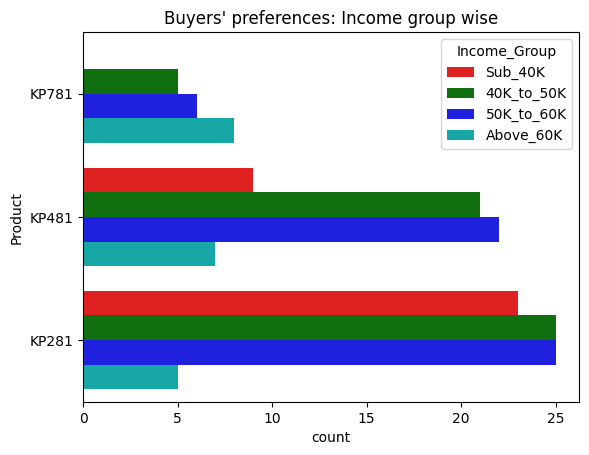

In [ ]:
sns.countplot(data=df_f, y='Product', hue = 'Income_Group', order=df_f.Product.value_counts(ascending=True).index, palette=['r', 'g', 'b', 'c' ] )
plt.title("Buyers' preferences: Income group wise")
plt.show()

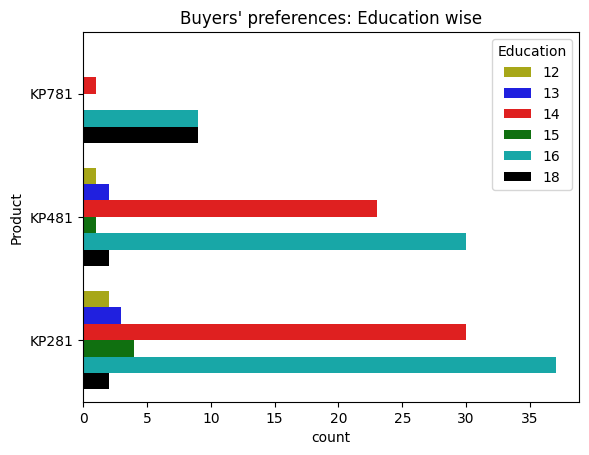

In [ ]:
sns.countplot(data=df_f, y='Product', hue = 'Education', order=df_f.Product.value_counts(ascending=True).index, palette=['y','b', 'r', 'g', 'c', 'k'])
plt.title("Buyers' preferences: Education wise")
plt.show()

In [ ]:
pd.cut(df_f.Income, 4, right=False).value_counts()

Income
[41469.25, 53376.5)      70
[53376.5, 65283.75)      42
[29562.0, 41469.25)      38
[65283.75, 77238.629)     6
Name: count, dtype: int64

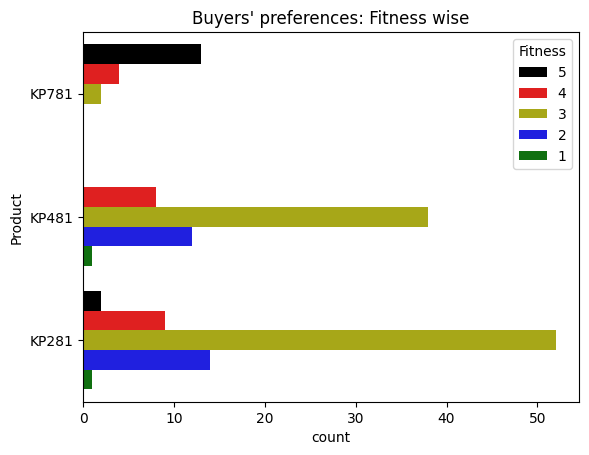

In [ ]:
sns.countplot(data=df_f, y='Product', hue = 'Fitness', hue_order=[5,4,3,2,1], order=df_f.Product.value_counts(ascending=[True]).index, palette=['k','r','y', 'b', 'g'])
plt.title("Buyers' preferences: Fitness wise")
plt.show()

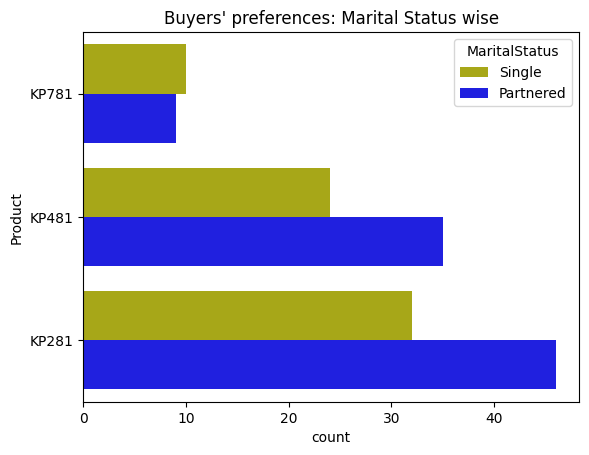

In [ ]:
sns.countplot(data=df_f, y='Product', hue = 'MaritalStatus', order=df_f.Product.value_counts(ascending=True).index, palette=['y','b'])
plt.title("Buyers' preferences: Marital Status wise")
plt.show()

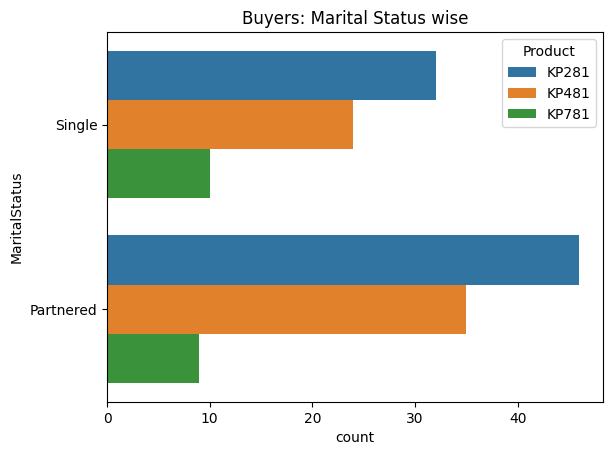

In [ ]:
sns.countplot(data=df_f,y='MaritalStatus', hue='Product',  order=df_f.MaritalStatus.value_counts(ascending=True).index)
plt.title('Buyers: Marital Status wise')
plt.show()

Gender,Female,Male,Total
0,39,39,78
1,29,30,59
2,3,16,19
3,71,85,156


In [ ]:
df_f['AgeBrackets']=pd.cut(df_f.Age, bins=[18, 25, 30, 35, 40, 45, 50], labels=['below25', '25to30', '30to35', '35to40', '40to45', 'above45' ] )

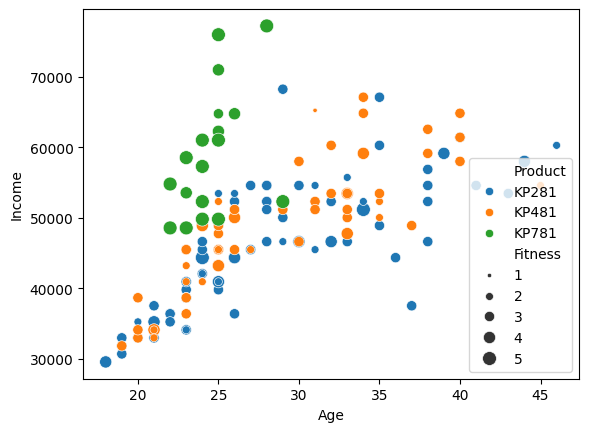

In [ ]:
sns.scatterplot(data=df_f, x='Age', y='Income', hue='Product',size='Fitness', sizes=(10, 100), hue_order=['KP281', 'KP481', 'KP781'])
plt.show()

In [ ]:
sns.bubble_plot(data=df_f, x='Age', y='Miles', size='Product', hue='Gender')
plt.show()

AttributeError: module 'seaborn' has no attribute 'bubble_plot'

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=False`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=False`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=False`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=False`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vec

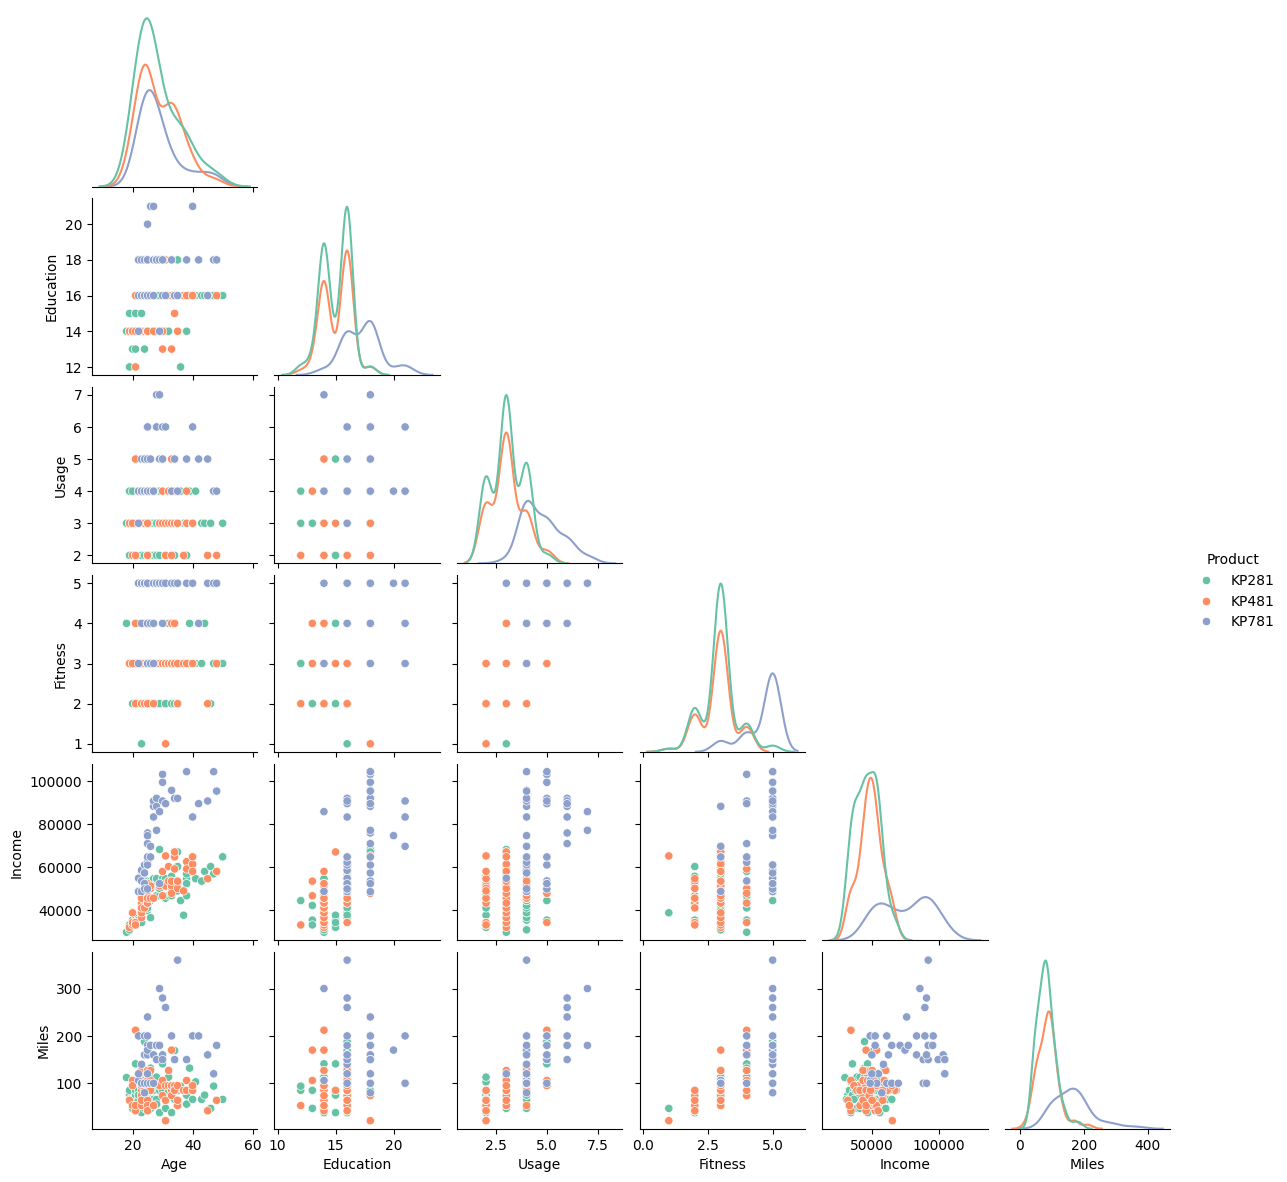

In [ ]:
sns.pairplot(data=df, hue='Product', corner=True, diag_kind='kde', palette='Set2', height=2, aspect=1, kind='scatter', diag_kws=dict(shade=False))
plt.show()

In [ ]:
df1=df.sort_values(by=['Age'], ascending=[True])

In [ ]:
IQR=(df.Age.quantile(0.75)-df.Age.quantile(0.25))
IQR

9.0

In [ ]:
L1=df.Age.quantile(0.25)-1.5*IQR
L2=df.Age.quantile(0.75)+1.5*IQR
L1, L2

(10.5, 46.5)

In [ ]:
df_cleaned=df[(df.Age>L1) & (df.Age<L2)]

In [ ]:
df_cleaned.size, df.size

(1575, 1620)

In [ ]:
L1=df.Age.quantile(0.95)
L2=df.Age.quantile(0.05)
L1, L2
df_c=df[df.Age==np.clip(df.Age, L1, L2)]

In [ ]:
df_c.size, df.size

(1494, 1620)

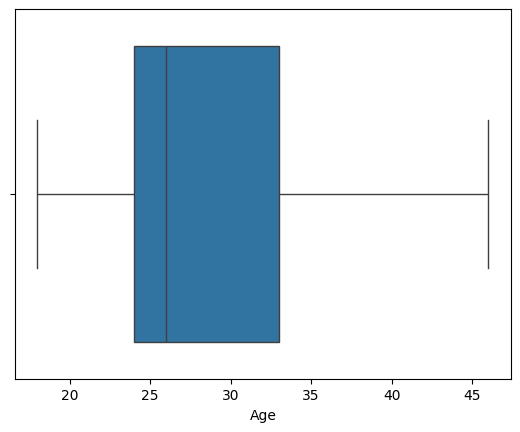

In [ ]:
sns.boxplot(data=df_cleaned, x='Age')
plt.show()

In [ ]:
df.Product.value_counts()

Product
KP281    80
KP481    60
KP781    40
Name: count, dtype: int64

In [ ]:
df.describe()

,Age,Education,Usage,Fitness,Income,Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,15.572222,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.617055,1.084797,0.958869,16506.684226,51.863605
min,18.000000,12.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,16.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,16.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,21.000000,7.000000,5.000000,104581.000000,360.000000


In [ ]:
df.Gender.value_counts()

Gender
Male      104
Female     76
Name: count, dtype: int64

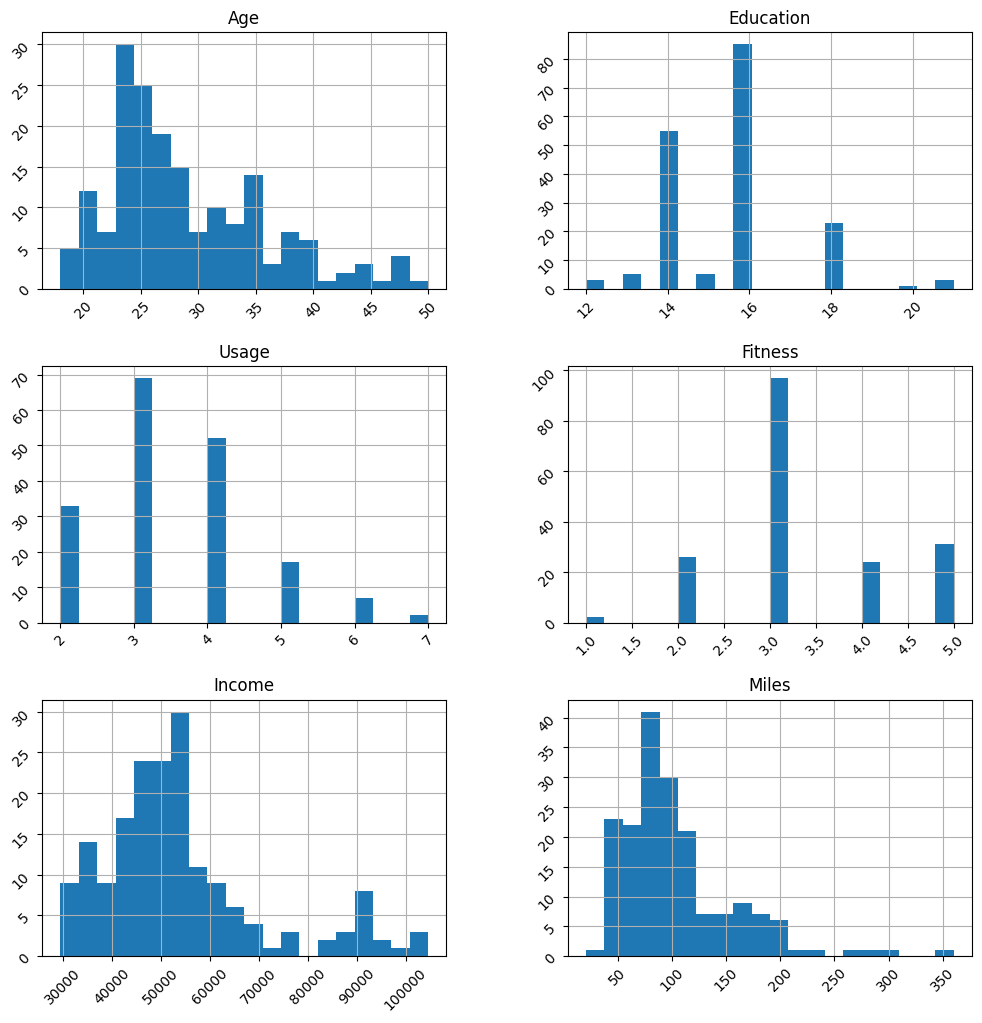

In [ ]:
df.hist(bins=20, figsize=(12,12), xrot=45, yrot=45 )
plt.show()

<ipython-input-39-c0b3fe1587d6>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Income)


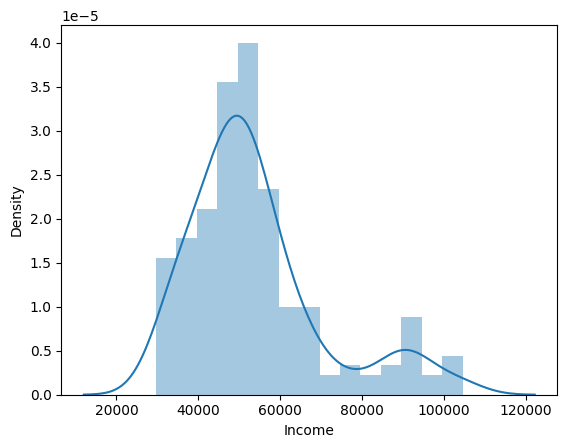

In [ ]:
sns.distplot(df.Income)
plt.show()

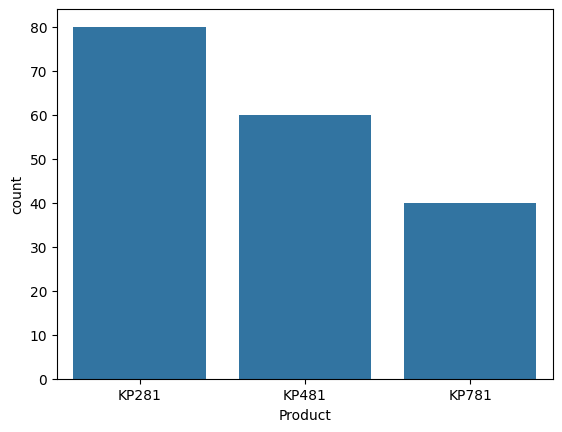

In [ ]:
sns.countplot(data=df, x='Product')
plt.show()

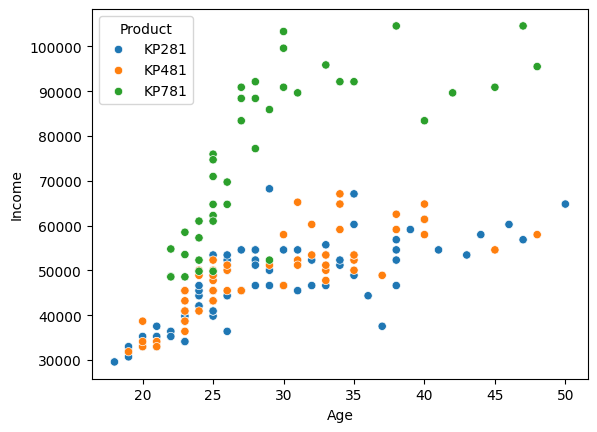

In [ ]:
sns.scatterplot(data=df, x='Age', y='Income', hue='Product')
plt.show()

AttributeError: 'FacetGrid' object has no attribute 'shade'

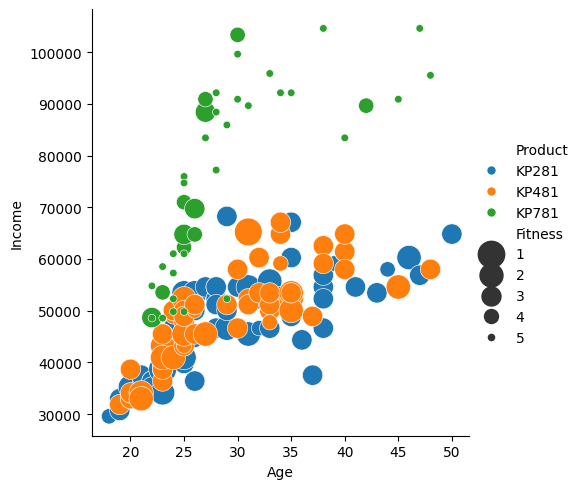

In [ ]:
sns.relplot(data=df, x='Age', y='Income',size='Fitness', sizes=(400,30), hue='Product').shade(.5)
plt.show()

In [ ]:
df.columns

Index(['Product', 'Age', 'Gender', 'Education', 'MaritalStatus', 'Usage',
       'Fitness', 'Income', 'Miles'],
      dtype='object')

In [ ]:
df.MaritalStatus.value_counts()

MaritalStatus
Partnered    107
Single        73
Name: count, dtype: int64

In [ ]:
df.Fitness.value_counts()

Fitness
3    97
5    31
2    26
4    24
1     2
Name: count, dtype: int64

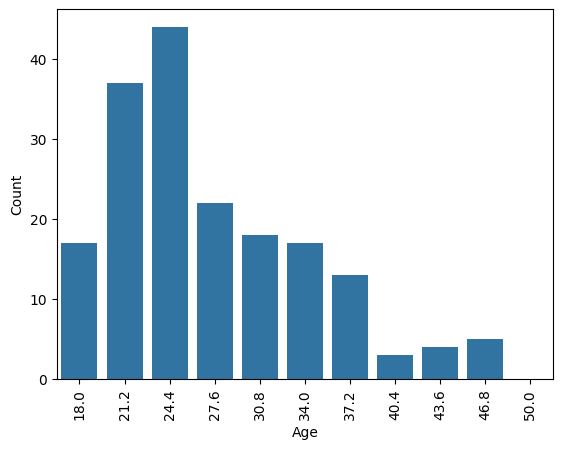

In [ ]:
df1=pd.DataFrame(np.histogram(df.Age)).T.round(2)
df1.columns=['Count', 'AgeBin']
sns.barplot(data=df1, x='AgeBin', y='Count')
plt.ylabel('Count')
plt.xlabel('Age')
plt.xticks(rotation=90)
plt.show()

In [ ]:
df.columns

Index(['Product', 'Age', 'Gender', 'Education', 'MaritalStatus', 'Usage',
       'Fitness', 'Income', 'Miles'],
      dtype='object')

In [ ]:
df.Product.value_counts()

Product
KP281    80
KP481    60
KP781    40
Name: count, dtype: int64

Text(0.5, 1.0, 'KP781')

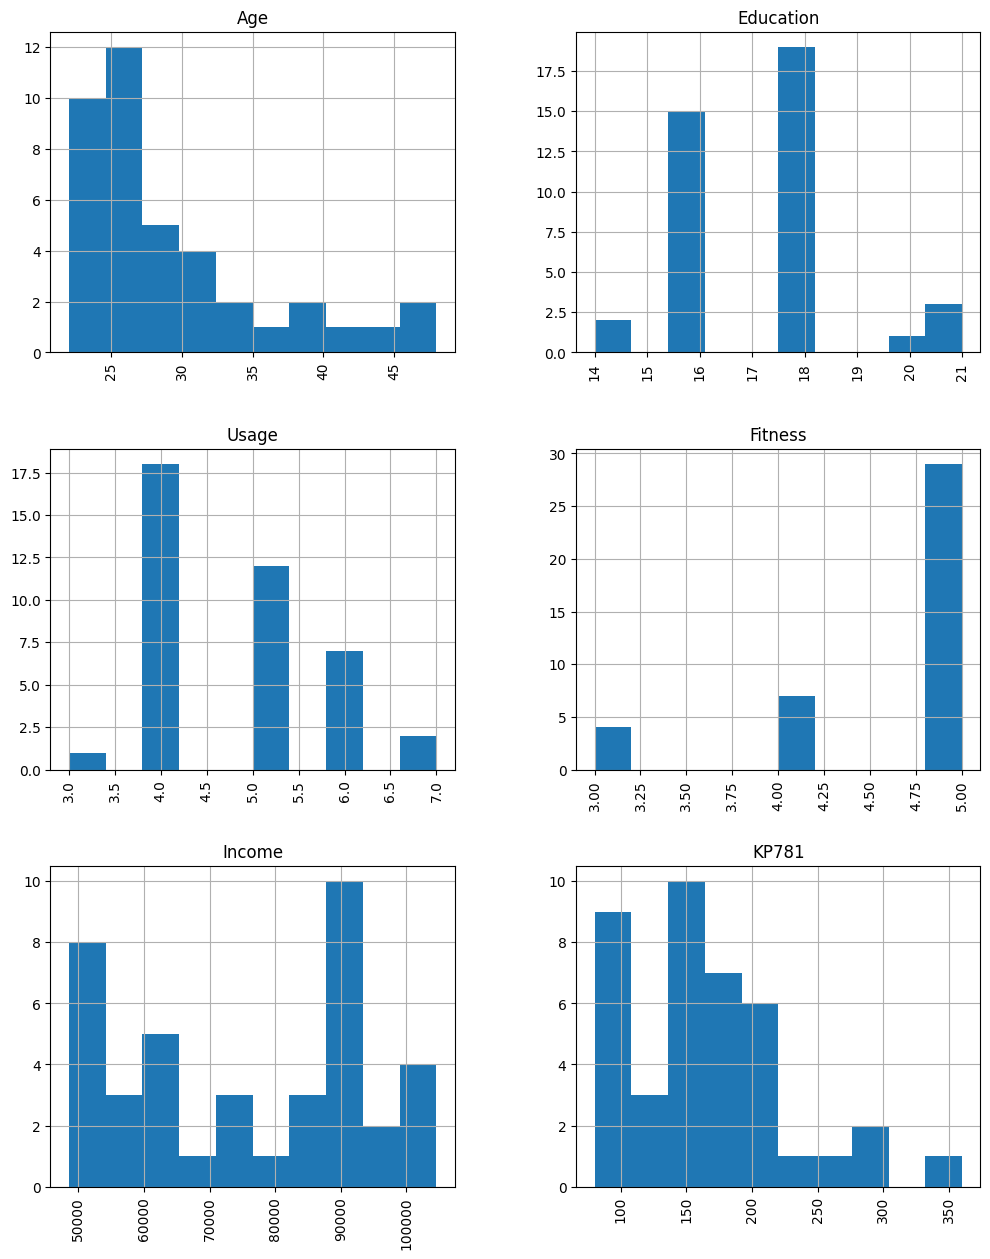

In [ ]:
df[df['Product']=='KP781'].hist(bins=10, figsize=(12,15), layout=(3,2), xrot=90 )
plt.title('KP781')

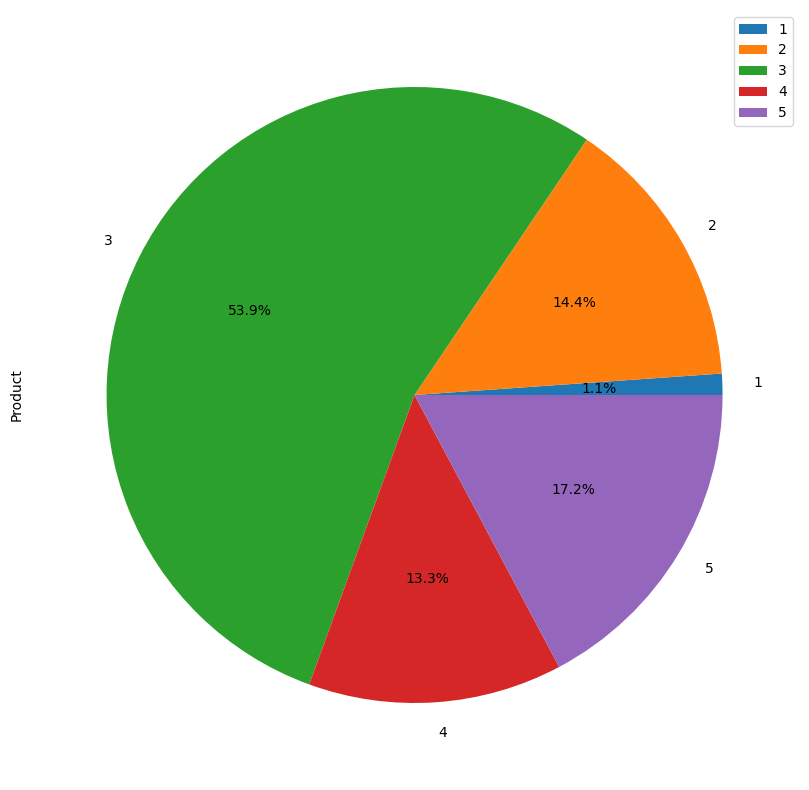

In [ ]:
df.groupby('Fitness').count().plot(kind='pie', y='Product', autopct='%1.1f%%', figsize=(10,10))
plt.show()

In [ ]:
pd.crosstab( index=df.Product, columns=df.Gender, margins=True, margins_name='Total', normalize=True).round(2)

Gender,Female,Male,Total
Product,,,
KP281,0.22,0.22,0.44
KP481,0.16,0.17,0.33
KP781,0.04,0.18,0.22
Total,0.42,0.58,1.00


In [ ]:
df.select_dtypes(include='int64').corr().sort_values(by='Age', ascending=False)

,Age,Education,Usage,Fitness,Income,Miles
Age,1.000000,0.280496,0.015064,0.061105,0.513414,0.036618
Income,0.513414,0.625827,0.519537,0.535005,1.000000,0.543473
Education,0.280496,1.000000,0.395155,0.410581,0.625827,0.307284
Fitness,0.061105,0.410581,0.668606,1.000000,0.535005,0.785702
Miles,0.036618,0.307284,0.759130,0.785702,0.543473,1.000000
Usage,0.015064,0.395155,1.000000,0.668606,0.519537,0.759130


In [ ]:
df[df.Product=='KP281'].describe()

,Age,Education,Usage,Fitness,Income,Miles
count,80.000000,80.000000,80.000000,80.00000,80.00000,80.000000
mean,28.550000,15.037500,3.087500,2.96250,46418.02500,82.787500
std,7.221452,1.216383,0.782624,0.66454,9075.78319,28.874102
min,18.000000,12.000000,2.000000,1.00000,29562.00000,38.000000
25%,23.000000,14.000000,3.000000,3.00000,38658.00000,66.000000
50%,26.000000,16.000000,3.000000,3.00000,46617.00000,85.000000
75%,33.000000,16.000000,4.000000,3.00000,53439.00000,94.000000
max,50.000000,18.000000,5.000000,5.00000,68220.00000,188.000000


In [ ]:
df[df.Product=='KP481'].describe()

,Age,Education,Usage,Fitness,Income,Miles
count,60.000000,60.000000,60.000000,60.00000,60.000000,60.000000
mean,28.900000,15.116667,3.066667,2.90000,48973.650000,87.933333
std,6.645248,1.222552,0.799717,0.62977,8653.989388,33.263135
min,19.000000,12.000000,2.000000,1.00000,31836.000000,21.000000
25%,24.000000,14.000000,3.000000,3.00000,44911.500000,64.000000
50%,26.000000,16.000000,3.000000,3.00000,49459.500000,85.000000
75%,33.250000,16.000000,3.250000,3.00000,53439.000000,106.000000
max,48.000000,18.000000,5.000000,4.00000,67083.000000,212.000000


In [ ]:
df[df.Product=='KP781'].describe()

,Age,Education,Usage,Fitness,Income,Miles
count,40.000000,40.000000,40.000000,40.000000,40.00000,40.000000
mean,29.100000,17.325000,4.775000,4.625000,75441.57500,166.900000
std,6.971738,1.639066,0.946993,0.667467,18505.83672,60.066544
min,22.000000,14.000000,3.000000,3.000000,48556.00000,80.000000
25%,24.750000,16.000000,4.000000,4.000000,58204.75000,120.000000
50%,27.000000,18.000000,5.000000,5.000000,76568.50000,160.000000
75%,30.250000,18.000000,5.000000,5.000000,90886.00000,200.000000
max,48.000000,21.000000,7.000000,5.000000,104581.00000,360.000000


/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=False`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=False`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=False`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=False`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vec

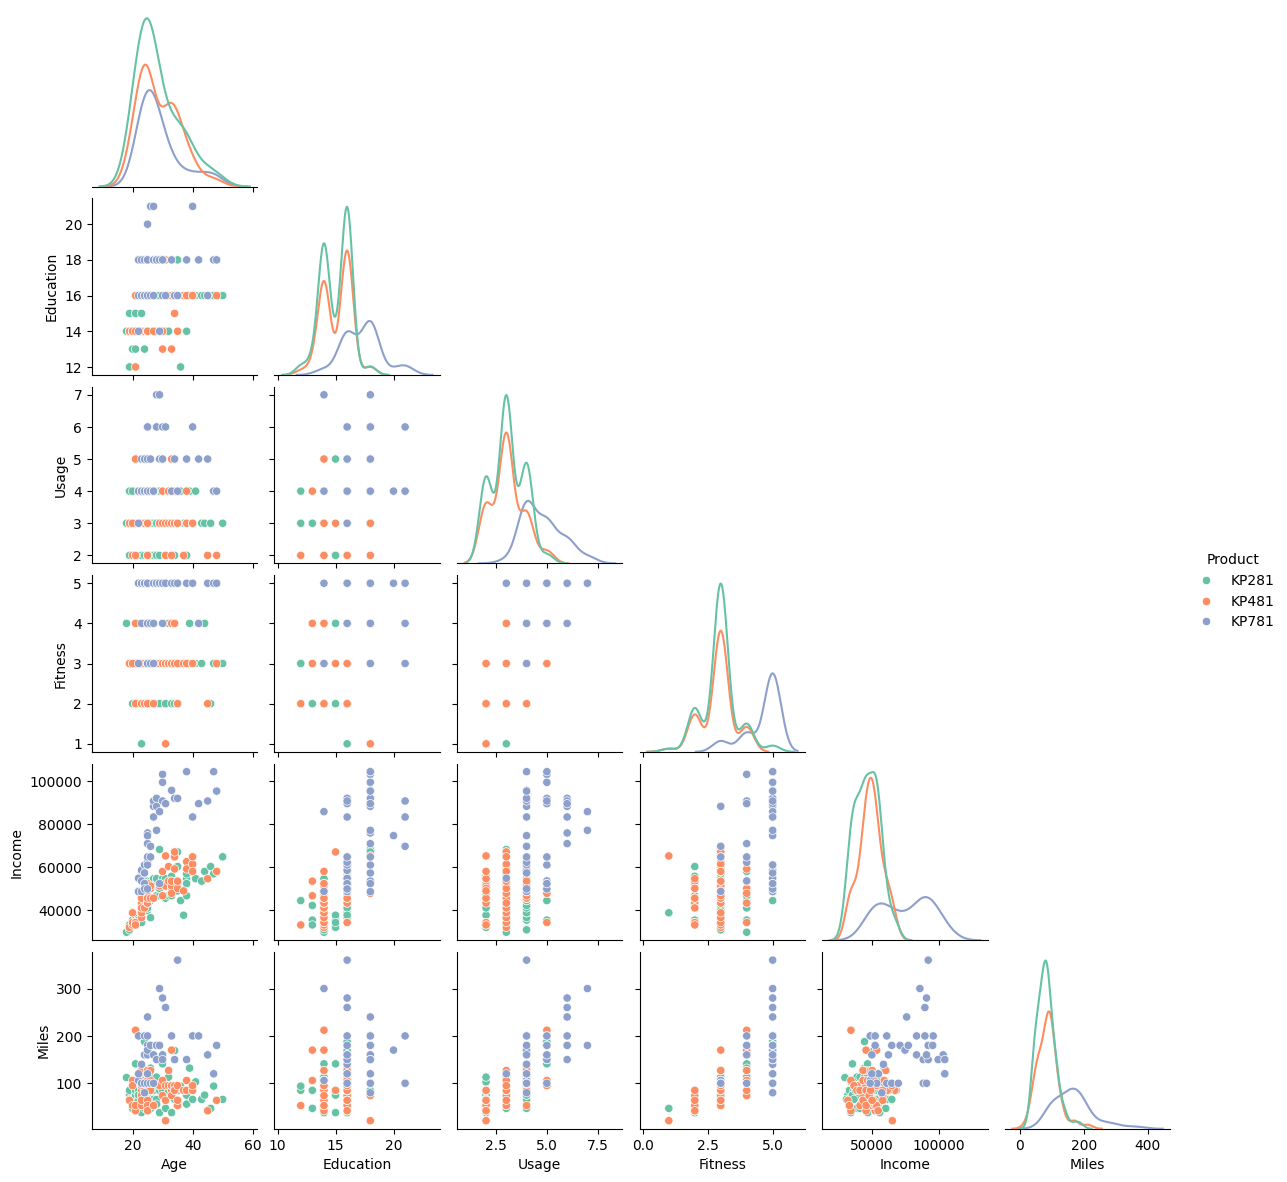

In [ ]:
sns.pairplot(data=df, hue='Product', corner=True, diag_kind='kde', palette='Set2', height=2, aspect=1, kind='scatter', diag_kws=dict(shade=False))
plt.show()

In [ ]:
df.Gender.unique()

array(['Male', 'Female'], dtype=object)

In [ ]:
df.Usage.unique()

array([3, 2, 4, 5, 6, 7])

In [ ]:
df.Fitness.unique()

array([4, 3, 2, 1, 5])

In [ ]:
df.Income.max(), df.Income.min(), df.Income.mean()

(104581, 29562, 53719.57777777778)